In [ ]:
!pip install gymnasium minigrid stable-baselines3[extra] matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 14.0 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import minigrid
from minigrid.wrappers import FullyObsWrapper
import matplotlib.pyplot as plt

# MiniGrid ortamını oluştur
env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
env = FullyObsWrapper(env)  # Tam gözlem (tüm ızgarayı gösterir)

print("Eylem Uzayı:", env.action_space)
print("Gözlem Uzayı:", env.observation_space)

# Rastgele bir bölüm çalıştır
obs, info = env.reset()
done = False
total_reward = 0
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward


print(f"Bölüm toplam ödül: {total_reward}")



Eylem Uzayı: Discrete(7)
Gözlem Uzayı: Dict('direction': Discrete(4), 'image': Box(0, 255, (8, 8, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7ac0681c6840>, None))
Bölüm toplam ödül: 0


In [ ]:
import numpy as np

def compute_reward(obs, terminated, info, current_pos, prev_pos, goal_pos=(6, 6)):
    """
    Gelişmiş Ödül Fonksiyonu.
    """
    reward = 0

    reward -= 0.01

    # 2. HEDEFE ULAŞMA DURUMU
    if terminated:
        return 10.0


    # 3. DUVARA TAKILMA VE HAREKET KONTROLÜ
    if prev_pos is not None:
        if np.array_equal(current_pos, prev_pos):
            reward -= 1.0
        else:
            # 4. HEDEFE YAKLAŞMA ÖDÜLÜ (Manhattan Mesafesi)
            # Robot hedefe yaklaşıyorsa ödül ver, uzaklaşıyorsa ceza ver.
            prev_dist = abs(prev_pos[0] - goal_pos[0]) + abs(prev_pos[1] - goal_pos[1])
            curr_dist = abs(current_pos[0] - goal_pos[0]) + abs(current_pos[1] - goal_pos[1])

            if curr_dist < prev_dist:
                reward += 0.1
            elif curr_dist > prev_dist:
                reward -= 0.1

    return reward

In [ ]:
from gymnasium import Wrapper
from minigrid.wrappers import FlatObsWrapper
import numpy as np

class CustomRewardWrapper(Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.prev_pos = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_pos = self.env.unwrapped.agent_pos
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        current_pos = self.env.unwrapped.agent_pos
        reward = compute_reward(obs, terminated, info, current_pos, self.prev_pos, goal_pos=(6, 6))
        self.prev_pos = current_pos

        return obs, reward, terminated, truncated, info


# Sarılmış ortamı oluştur
base_env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
base_env = FullyObsWrapper(base_env)
base_env = FlatObsWrapper(base_env)
env = CustomRewardWrapper(base_env)

In [ ]:
from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv

def record_video(model, env_id, video_name, video_folder='videos/'):
    def make_env():
        env = gym.make(env_id, render_mode='rgb_array')
        env = FullyObsWrapper(env)
        env = FlatObsWrapper(env)
        env = CustomRewardWrapper(env)
        return env


    vec_env = DummyVecEnv([make_env])
    vec_env = VecVideoRecorder(
        vec_env,
        video_folder,
        record_video_trigger=lambda x: x == 0,
        video_length=500,
        name_prefix=video_name
    )

    obs = vec_env.reset()
    for _ in range(200):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = vec_env.step(action)
        if done:
            break
    vec_env.close()



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Başlıyor: Deney1
✅ Tamamlandı → Başarı: %100.0 | Ödül: 9.80

Başlıyor: Deney2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Tamamlandı → Başarı: %0.0 | Ödül: -253.06

Başlıyor: Deney3
✅ Tamamlandı → Başarı: %100.0 | Ödül: 9.80

Başlıyor: Deney4
✅ Tamamlandı → Başarı: %0.0 | Ödül: -253.06


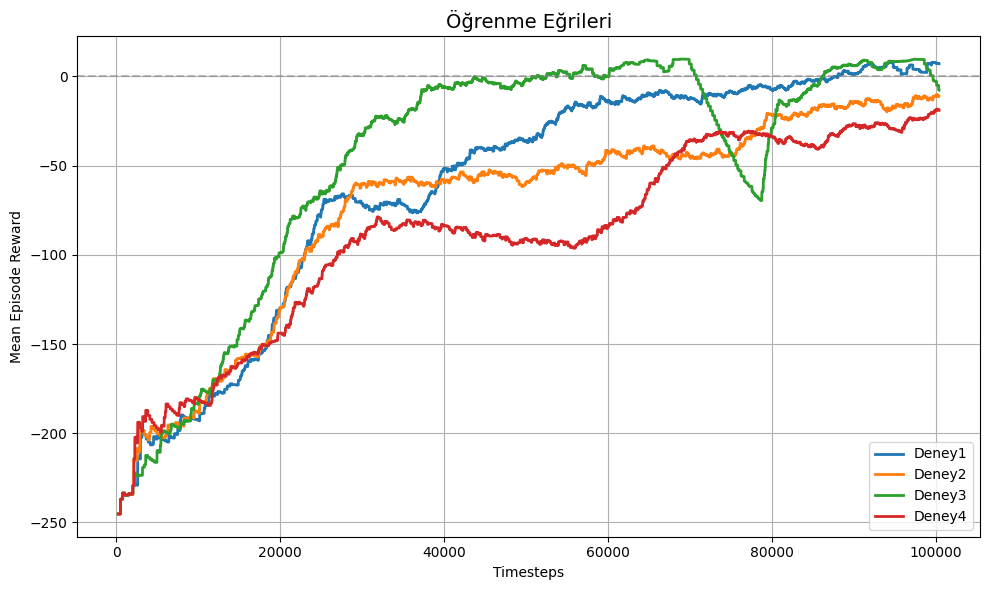

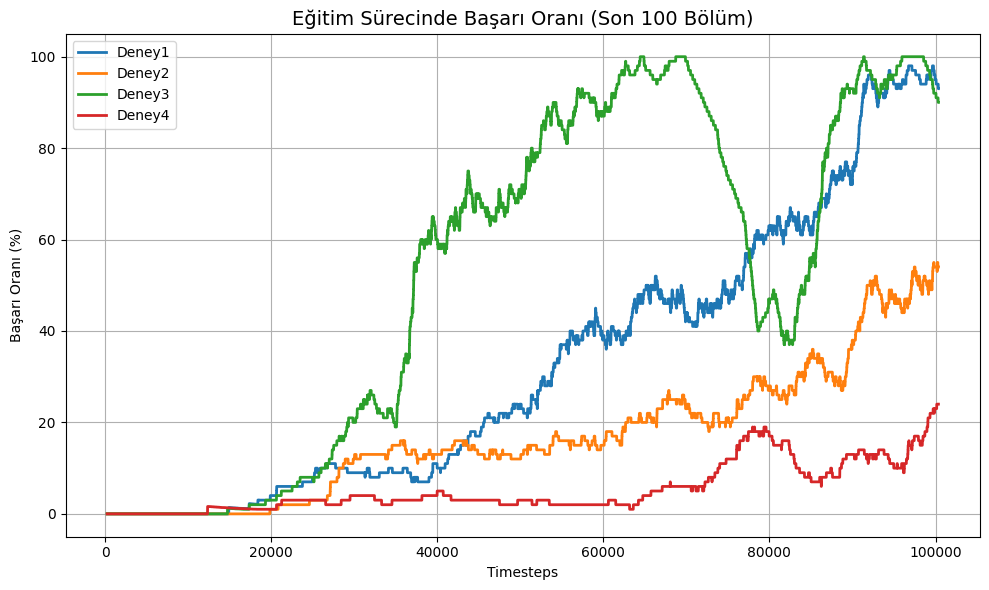

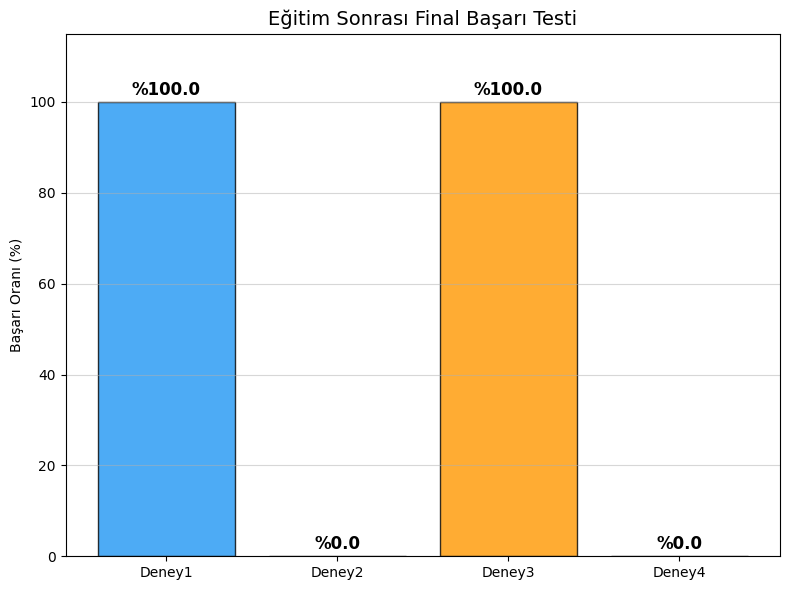

Bütün grafikler kaydedildi.

ÖZET TABLO
 Deney     LR  Gamma  Ent Coef Başarı Oranı  Ort. Ödül
Deney1 0.0003   0.99      0.00       %100.0       9.80
Deney2 0.0001   0.99      0.00         %0.0    -253.06
Deney3 0.0003   0.95      0.00       %100.0       9.80
Deney4 0.0003   0.99      0.05         %0.0    -253.06


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Öğrenme eğrisi kaydeden callback

class LearningCurveCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.timesteps = []
        self.rewards = []
        self.success_rates = []

    def _on_step(self):
        if len(self.model.ep_info_buffer) > 0:
            mean_reward = np.mean([ep["r"] for ep in self.model.ep_info_buffer])
            self.timesteps.append(self.num_timesteps)
            self.rewards.append(mean_reward)

            success_count = sum(1 for ep in self.model.ep_info_buffer if ep.get("is_success", ep["r"] > 0))
            current_success_rate = (success_count / len(self.model.ep_info_buffer)) * 100
            self.success_rates.append(current_success_rate)

        return True

# Son 100 bölüm başarı oranı hesapla

def compute_success_rate(model, env, n_episodes=100):
    successes = 0
    for _ in range(n_episodes):
        obs, info = env.reset()
        for _ in range(256):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            if terminated:
                successes += 1  # hedefe ulaştı
                break
            if truncated:
                break           # zaman aşımı, başarısız
    return successes / n_episodes * 100

# Deneyler
experiments = [
    {"name": "Deney1",   "learning_rate": 3e-4, "gamma": 0.99, "ent_coef": 0.0},
    {"name": "Deney2",    "learning_rate": 1e-4, "gamma": 0.99, "ent_coef": 0.0},
    {"name": "Deney3", "learning_rate": 3e-4, "gamma": 0.95, "ent_coef": 0.0},
    {"name": "Deney4",    "learning_rate": 3e-4, "gamma": 0.99, "ent_coef": 0.05},
]

all_curves = {}  # öğrenme eğrileri
results = []     # özet tablo

for config in experiments:
    print(f"\n{'='*50}\nBaşlıyor: {config['name']}")

    # Ortam
    base_env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
    base_env = FullyObsWrapper(base_env)
    base_env = FlatObsWrapper(base_env)
    env = CustomRewardWrapper(base_env)

    # Callback
    curve_cb = LearningCurveCallback()

    # Model
    model = PPO(
        "MlpPolicy", env,
        learning_rate=config["learning_rate"],
        gamma=config["gamma"],
        ent_coef=config["ent_coef"],
        seed=42,
        verbose=0,
        tensorboard_log="./ppo_minigrid_tb/"
    )

    # Eğit
    model.learn(
        total_timesteps=100000,
        callback=curve_cb,
        tb_log_name=config["name"]
    )

    # Öğrenme eğrisini kaydet
    all_curves[config["name"]] = {
        "timesteps": curve_cb.timesteps,
        "rewards":   curve_cb.rewards,
        "success_rates": curve_cb.success_rates
    }

    # Başarı oranı
    success_rate = compute_success_rate(model, env)

    # Ortalama test ödülü
    test_rewards = []
    for _ in range(100):
        obs, info = env.reset()
        total_r = 0
        for _ in range(256):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_r += reward
            if terminated or truncated:
                break
        test_rewards.append(total_r)

    results.append({
        "Deney":        config["name"],
        "LR":           config["learning_rate"],
        "Gamma":        config["gamma"],
        "Ent Coef":     config["ent_coef"],
        "Başarı Oranı": f"%{success_rate:.1f}",
        "Ort. Ödül":    round(np.mean(test_rewards), 2),
    })


    model.save(f"model_{config['name']}")
    print(f"✅ Tamamlandı → Başarı: %{success_rate:.1f} | Ödül: {np.mean(test_rewards):.2f}")
    env.close()

#  Karşılaştırmalı grafikler

# 1. GRAFİK: ÖĞRENME EĞRİLERİ (ÖDÜL) ---
plt.figure(figsize=(10, 6))
for name, curve in all_curves.items():
    plt.plot(curve["timesteps"], curve["rewards"], label=name, linewidth=2)
plt.title("Öğrenme Eğrileri", fontsize=14)
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Reward")
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("1_ogrenme_egrisi.png", dpi=150, bbox_inches='tight')
plt.show()

# 2. GRAFİK: EĞİTİM SIRASI BAŞARI ORANI ---
plt.figure(figsize=(10, 6))
for name, curve in all_curves.items():
    plt.plot(curve["timesteps"], curve["success_rates"], label=name, linewidth=2)
plt.title("Eğitim Sürecinde Başarı Oranı (Son 100 Bölüm)", fontsize=14)
plt.xlabel("Timesteps")
plt.ylabel("Başarı Oranı (%)")
plt.ylim(-5, 105)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("2_egitim_basari_orani.png", dpi=150, bbox_inches='tight')
plt.show()


# 3. GRAFİK: EĞİTİM SONRASI FİNAL BAŞARI (BAR GRAFİĞİ) ---
plt.figure(figsize=(8, 6))
names = [r["Deney"].replace("_", "\n") for r in results]
success_values = [float(r["Başarı Oranı"].replace("%", "")) for r in results]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

bars = plt.bar(names, success_values, color=colors, alpha=0.8, edgecolor='black')
plt.title("Eğitim Sonrası Final Başarı Testi", fontsize=14)
plt.ylabel("Başarı Oranı (%)")
plt.ylim(0, 115)
plt.grid(True, axis='y', alpha=0.5)


for bar, val in zip(bars, success_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"%{val:.1f}", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("3_final_basari_testi.png", dpi=150, bbox_inches='tight')
plt.show()

print("Bütün grafikler kaydedildi.")

# Özet tablo
print("\n" + "="*70)
print("ÖZET TABLO")
print("="*70)
print(pd.DataFrame(results).to_string(index=False))



In [ ]:
# Eğitilmiş modelleri test et ve video kaydetme
for config in experiments:
    print(f"\n{'='*50}\nTest ediliyor: {config['name']}")

    # Ortam
    base_env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
    base_env = FullyObsWrapper(base_env)
    base_env = FlatObsWrapper(base_env)
    test_env = CustomRewardWrapper(base_env)

    # Modeli yükle
    model = PPO.load(f"model_{config['name']}")

    # Test et
    success_rate = compute_success_rate(model, test_env)
    print(f"Başarı Oranı: %{success_rate:.1f}")

    # Video kaydet
    record_video(model, 'MiniGrid-Empty-8x8-v0', f"model_{config['name']}")
    print(f"Video kaydedildi: model_{config['name']}")

    test_env.close()


Test ediliyor: Deney1
Başarı Oranı: %100.0


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Moviepy - Building video /content/videos/model_Deney1-step-0-to-step-500.mp4.
Moviepy - Writing video /content/videos/model_Deney1-step-0-to-step-500.mp4



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Moviepy - Done !
Moviepy - video ready /content/videos/model_Deney1-step-0-to-step-500.mp4
Video kaydedildi: model_Deney1

Test ediliyor: Deney2
Başarı Oranı: %0.0
Moviepy - Building video /content/videos/model_Deney2-step-0-to-step-500.mp4.
Moviepy - Writing video /content/videos/model_Deney2-step-0-to-step-500.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/model_Deney2-step-0-to-step-500.mp4
Video kaydedildi: model_Deney2

Test ediliyor: Deney3
Başarı Oranı: %0.0
Moviepy - Building video /content/videos/model_Deney3-step-0-to-step-500.mp4.
Moviepy - Writing video /content/videos/model_Deney3-step-0-to-step-500.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/model_Deney3-step-0-to-step-500.mp4
Video kaydedildi: model_Deney3

Test ediliyor: Deney4
Başarı Oranı: %0.0
Moviepy - Building video /content/videos/model_Deney4-step-0-to-step-500.mp4.
Moviepy - Writing video /content/videos/model_Deney4-step-0-to-step-500.mp4



Moviepy - Done !
Moviepy - video ready /content/videos/model_Deney4-step-0-to-step-500.mp4
Video kaydedildi: model_Deney4
